In [ ]:
# Import Labraries
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Data & Cleaning
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply ( lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter the data 
job_title = "Data Analyst"
df= df[df['job_title_short']==job_title]

# Your mession here is to customise the chart to look better

In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 196075 entries, 1 to 785737
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        196075 non-null  str           
 1   job_title              196075 non-null  str           
 2   job_location           195801 non-null  str           
 3   job_via                196067 non-null  str           
 4   job_schedule_type      191475 non-null  str           
 5   job_work_from_home     196075 non-null  bool          
 6   search_location        196075 non-null  str           
 7   job_posted_date        196075 non-null  datetime64[us]
 8   job_no_degree_mention  196075 non-null  bool          
 9   job_health_insurance   196075 non-null  bool          
 10  job_country            196067 non-null  str           
 11  salary_rate            9746 non-null    str           
 12  salary_year_avg        5451 non-null    float64       
 13  

In [5]:
# Extarcting the number of the months in a new column
df['month_no'] = df['job_posted_date'].dt.month
# Explode the data 
df_exploded = df.explode('job_skills')
# Make the pivot table 
df_FEP = df_exploded.pivot_table(
    index = 'month_no' , 
    columns= 'job_skills' ,
    aggfunc='size' ,
    fill_value=0     # this fill all the NaN by 0
)
                # Note : FEP mean Filtered Exploded Pivot

# Now Let's Sort this values 
# Create the totol row to use it for sorting
df_FEP.loc['total'] = df_FEP.sum()
# We sort the totol row , using the index 
df_FEP = df_FEP [df_FEP.loc['total'].sort_values(ascending=False).index]
# Delete the total row 
df_FEP = df_FEP.drop('total')

<Axes: xlabel='month_no'>

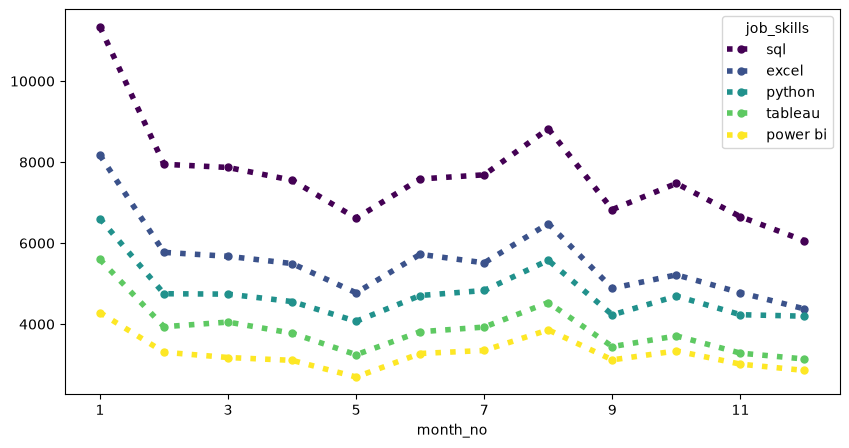

In [15]:
# the Chart
df_FEP.iloc[ : , :5].plot(
    kind='line' ,
    linewidth = '4' ,
    linestyle = ':' ,            # options : ':'  ,  '-'  ,  '--'  , '-.'
    colormap = 'viridis' ,
    marker = 'o' ,               # options : o x + s * , . 1 2 3 4 .... 
    markersize = 5 , 
    figsize = ( 10 , 5)
    )